<p style="font-family:Times New Roman; font-size:32px;">
Cognitive Modeling - Final Project
</p>

In [ ]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import arviz as az
from cmdstanpy import CmdStanModel
np.random.seed(42)

C:\Users\hwli2\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
# Load data from training data
def load_data(filepath: str) -> pd.DataFrame:
    return pd.read_csv(filepath)

df = load_data("training_data.csv")
df.head()

# Print data summary statistics
def summarize_data(dataframe: pd.DataFrame) -> None:
    print(dataframe.describe())

summarize_data(df)

             y      cost   success   emotion
count  4.00000  4.000000  4.000000  4.000000
mean   0.50000  0.725000  0.500000  0.700000
std    0.57735  0.170783  0.294392  0.294392
min    0.00000  0.500000  0.200000  0.400000
25%    0.00000  0.650000  0.275000  0.475000
50%    0.50000  0.750000  0.500000  0.700000
75%    1.00000  0.825000  0.725000  0.925000
max    1.00000  0.900000  0.800000  1.000000


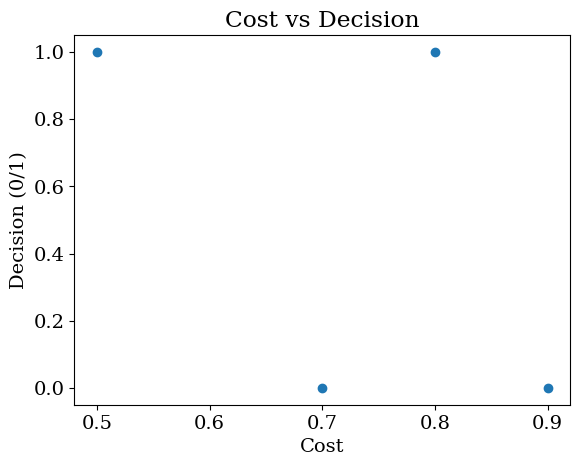

In [12]:
# Data visualization: cost vs decision
def plot_cost_vs_decision(dataframe: pd.DataFrame) -> None:
    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 14,
    })

    plt.scatter(dataframe["cost"], dataframe["y"])
    plt.xlabel("Cost")
    plt.ylabel("Decision (0/1)")
    plt.title("Cost vs Decision")
    plt.show()


plot_cost_vs_decision(df)

In [13]:
def prepare_stan_data(dataframe: pd.DataFrame) -> dict:
    """Convert dataframe into Stan-compatible format."""
    return {
        "N": len(dataframe),
        "cost": dataframe["cost"].values,
        "success": dataframe["success"].values,
        "emotion": dataframe["emotion"].values,
        "y": dataframe["y"].astype(int).values,
    }
stan_data = prepare_stan_data(df)

def run_model(stan_file: str, data: dict):
    """Compile and run Stan model."""
    model = CmdStanModel(stan_file=stan_file)

    fit = model.sample(
        data=data,
        chains=4,
        iter_sampling=1000,
        iter_warmup=1000,
        seed=42,
    )

    return fit
fit = run_model("model.stan", stan_data)

18:05:49 - cmdstanpy - INFO - compiling stan file C:\Users\hwli2\Dropbox\PC\Desktop\COGMOD~1\COGMOD~1\model.stan to exe file C:\Users\hwli2\Dropbox\PC\Desktop\Cog Mod\CogMod-Final-Project\model.exe


ValueError: Failed to compile Stan model 'C:\Users\hwli2\Dropbox\PC\Desktop\Cog Mod\CogMod-Final-Project\model.stan'. Console:

Command: ['mingw32-make', 'STANCFLAGS+=--filename-in-msg=model.stan', 'C:/Users/hwli2/Dropbox/PC/Desktop/COGMOD~1/COGMOD~1/model.exe']
failed with error [WinError 2] The system cannot find the file specified

